In [2]:
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=(FutureWarning, UserWarning))

pd.set_option("display.max_columns", 100)

In [3]:
train = pd.read_csv("train_final.csv")

In [4]:
train["arrival_date"] = train.apply(
    lambda row: datetime(
        row.arrival_date_year,
        datetime.strptime(row.arrival_date_month, "%B").month,
        row.arrival_date_day_of_month),
    axis=1)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
train['arrival_date_day_of_week'] = pd.Categorical(train['arrival_date'].dt.day_name(), categories=day_order, ordered=True)

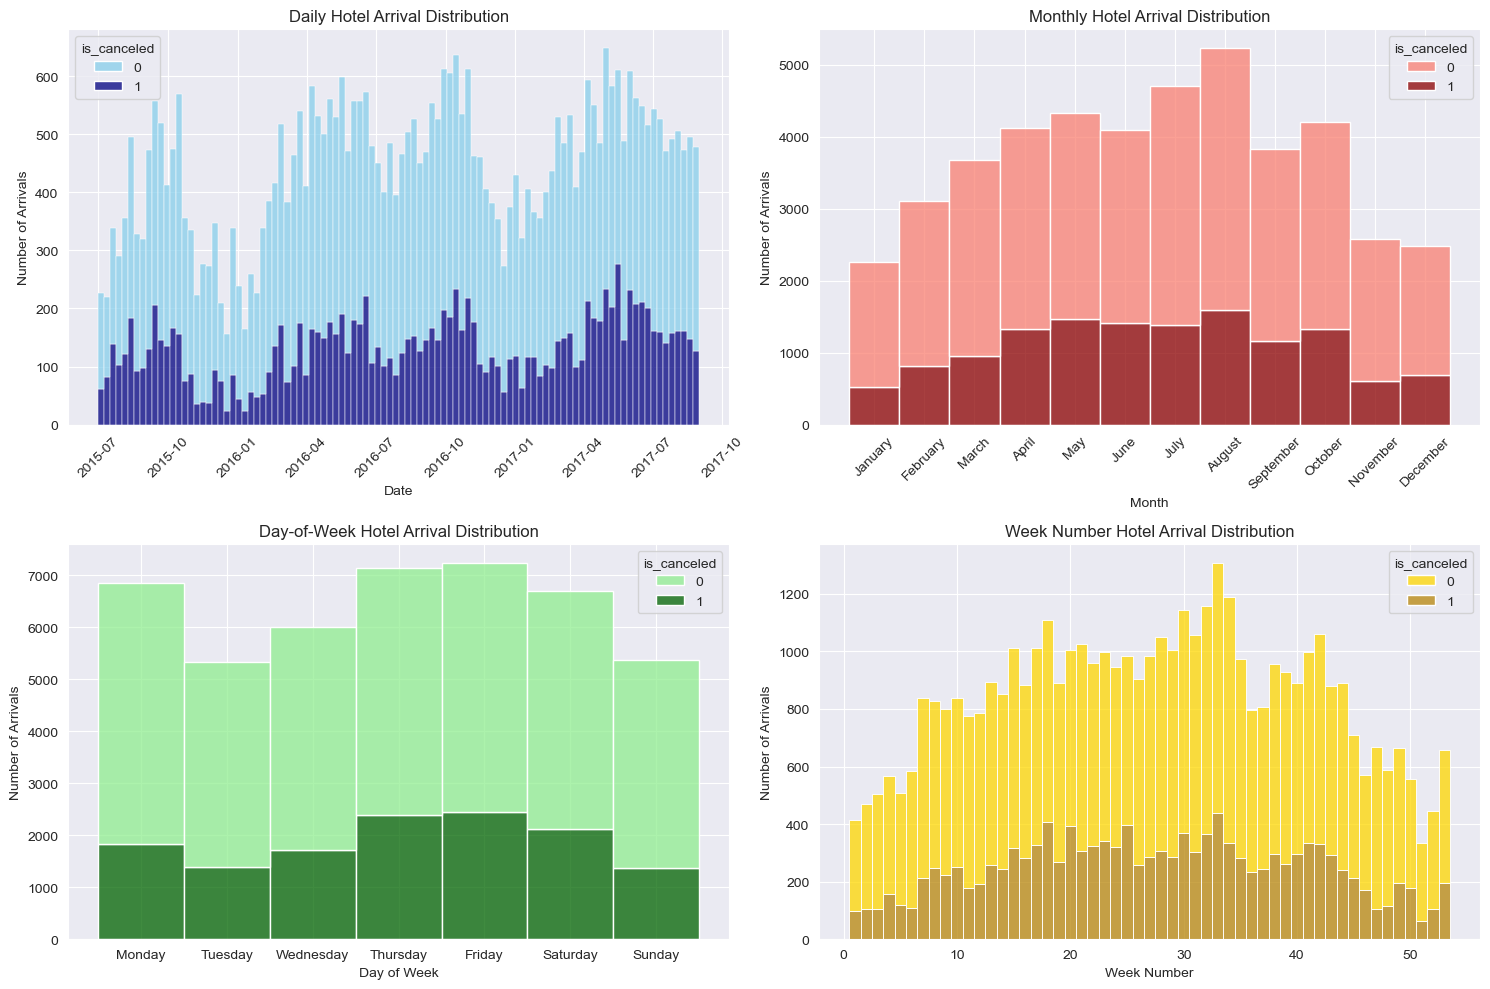

In [5]:
plt.figure(figsize=(15, 10))

# Daily arrivals
plt.subplot(2, 2, 1)
sns.histplot(data=train, x='arrival_date', hue='is_canceled', bins=100,
             multiple='stack', palette={0: 'skyblue', 1: 'navy'},
             edgecolor='white')
plt.title('Daily Hotel Arrival Distribution')
plt.xlabel('Date')
plt.ylabel('Number of Arrivals')
plt.xticks(rotation=45)

# Monthly arrivals
plt.subplot(2, 2, 2)
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
train['arrival_date_month'] = pd.Categorical(train['arrival_date_month'],
                                             categories=month_order, ordered=True)
sns.histplot(data=train, x='arrival_date_month', hue='is_canceled',
             bins=12, multiple='stack', palette={0: 'salmon', 1: 'darkred'},
             edgecolor='white', stat='count', discrete=True)
plt.title('Monthly Hotel Arrival Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Arrivals')
plt.xticks(rotation=45)

# Day of week arrivals
plt.subplot(2, 2, 3)
sns.histplot(data=train, x='arrival_date_day_of_week', hue='is_canceled',
             bins=7, multiple='stack', palette={0: 'lightgreen', 1: 'darkgreen'},
             edgecolor='white', stat='count', discrete=True)
plt.title('Day-of-Week Hotel Arrival Distribution')
plt.xlabel('Day of Week')
plt.ylabel('Number of Arrivals')

# Week number arrivals
plt.subplot(2, 2, 4)
sns.histplot(data=train, x='arrival_date_week_number', hue='is_canceled',
             bins=7, multiple='stack', palette={0: 'gold', 1: 'darkgoldenrod'},
             edgecolor='white', stat='count', discrete=True)
plt.title('Week Number Hotel Arrival Distribution')
plt.xlabel('Week Number')
plt.ylabel('Number of Arrivals')

plt.tight_layout()
plt.show()


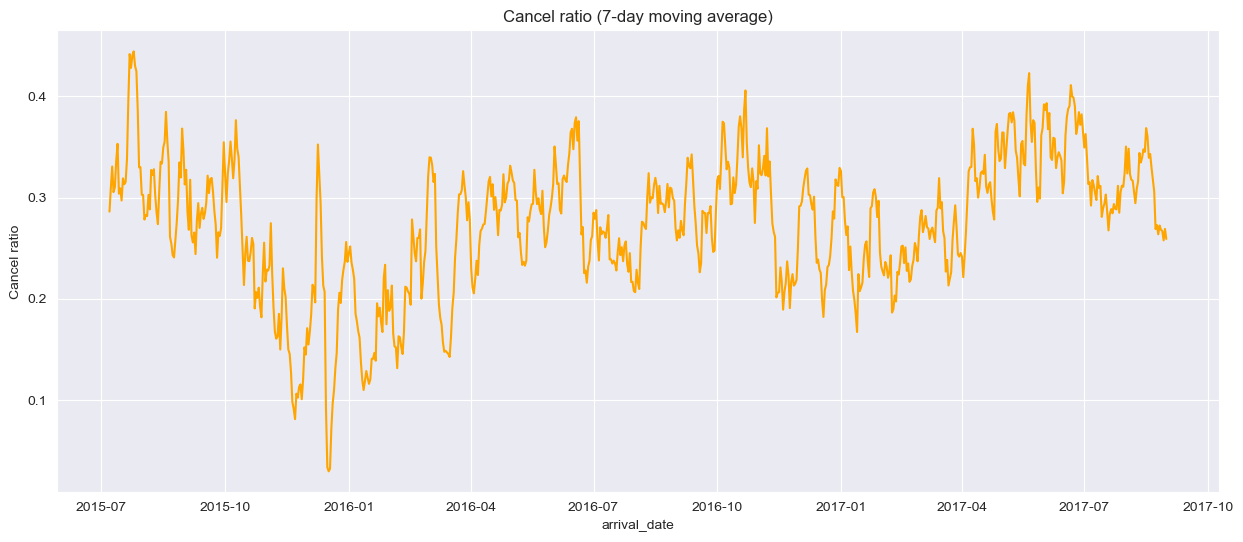

In [6]:
cancel_ratio = train.set_index('arrival_date').groupby(pd.Grouper(freq='D'))['is_canceled'].mean()

plt.figure(figsize=(15, 6))
ax1 = sns.lineplot(data=cancel_ratio.rolling(7).mean(), color='orange')
plt.ylabel('Cancel ratio')
plt.title('Cancel ratio (7-day moving average)')
plt.show()

Выводы:
- В структуре бронирований есть сезонность: пики бронирований и абсолютного количества отмен приходятся на лето.
- Четверг и пятница — наиболее популярные дни для заселения, но существенной разницы в доле отмен в разные дни недели не наблюдается.
- В июле 2016 года было падение бронирований в пик сезона, после чего количество бронирований снова выросло до своих пиков в сентябре
- В зимние месяцы 2015–2016 наблюдается минимум доли отмен (менее 20%, иногда ниже 10%). В тёплые месяцы и перед началом лета доля отмен снова растёт, достигая в отдельные пики 40% и выше. Заметна сезонная структура: зимой — минимум доли отмен, летом и ранней осенью — максимум.

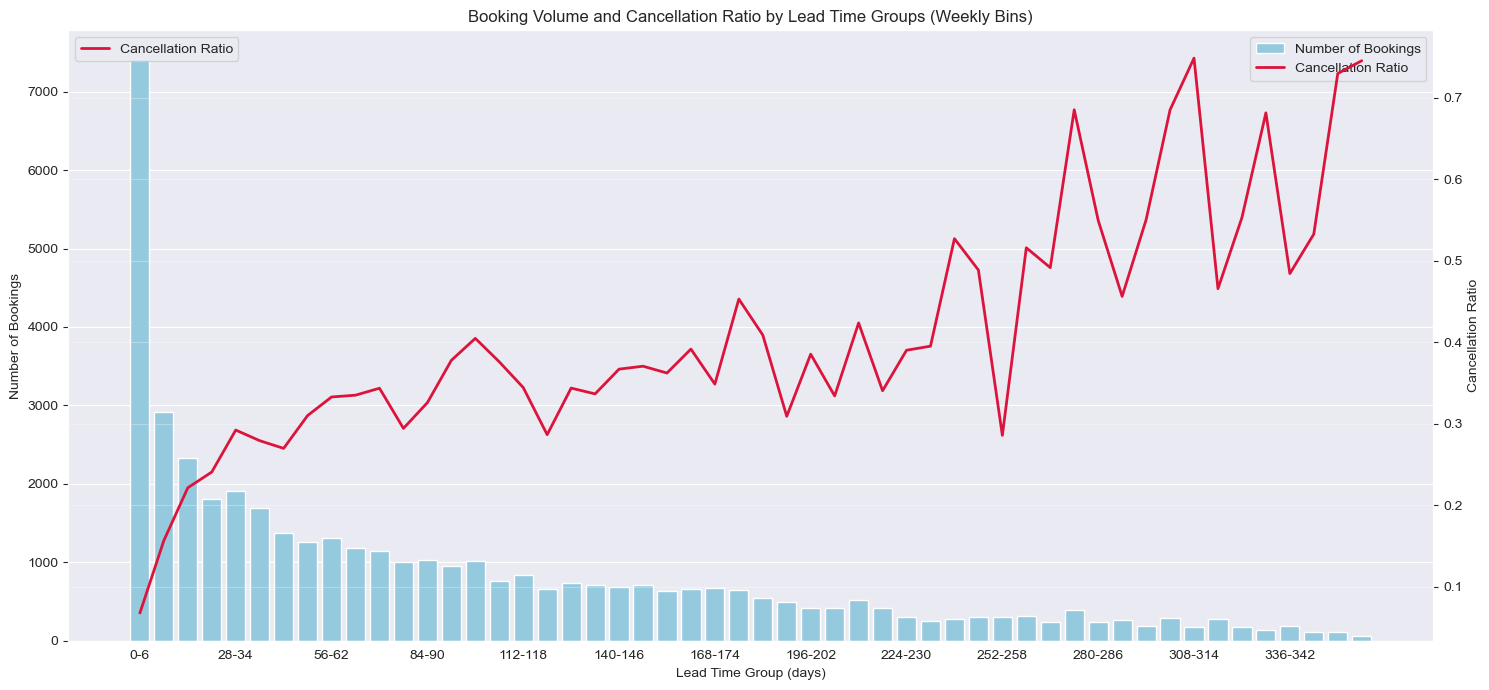

In [7]:
plt.figure(figsize=(15, 7))

bins = list(range(0, 366, 7))
labels = [f"{i}-{i+6}" for i in bins[:-1]]
train['lead_time_group'] = pd.cut(train['lead_time'], bins=bins, labels=labels, right=False)

group_counts = train['lead_time_group'].value_counts().sort_index()
cancel_ratio_grouped = train.set_index('lead_time_group').groupby("lead_time_group")['is_canceled'].mean()

ax1 = sns.barplot(x=group_counts.index, y=group_counts.values,
                 color='skyblue', label='Number of Bookings')
plt.xlabel('Lead Time Group (days)')
plt.ylabel('Number of Bookings')
plt.title('Booking Volume and Cancellation Ratio by Lead Time Groups (Weekly Bins)')

ax2 = plt.twinx()
sns.lineplot(
    x=np.arange(len(cancel_ratio_grouped)),
    y=cancel_ratio_grouped.values,
    color='crimson', linewidth=2, ax=ax2,
    label='Cancellation Ratio'
)
plt.ylabel('Cancellation Ratio')

plt.xticks(rotation=90, fontsize=8)
ax1.set_xticks(np.arange(0, len(labels), 4))
ax1.set_xticklabels(labels[::4])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


- По мере роста lead time доля отмен растёт. Для поздних пронирований (за несколько недель до даты заезда) доля отмен не превышает 30%, при этом чем меньше lead time, тем ниже доля отмен (при бронировании за неделю до заеда доля отмен ~5%).
- Для ранних бронирований за 2-8 месяцев до даты заезда доля отмен в среднем составляет ~35%. Для всех остальных бронирований (с датой заезда более чем через 8 месяцев) доля отмен может достигать 70% и выше.

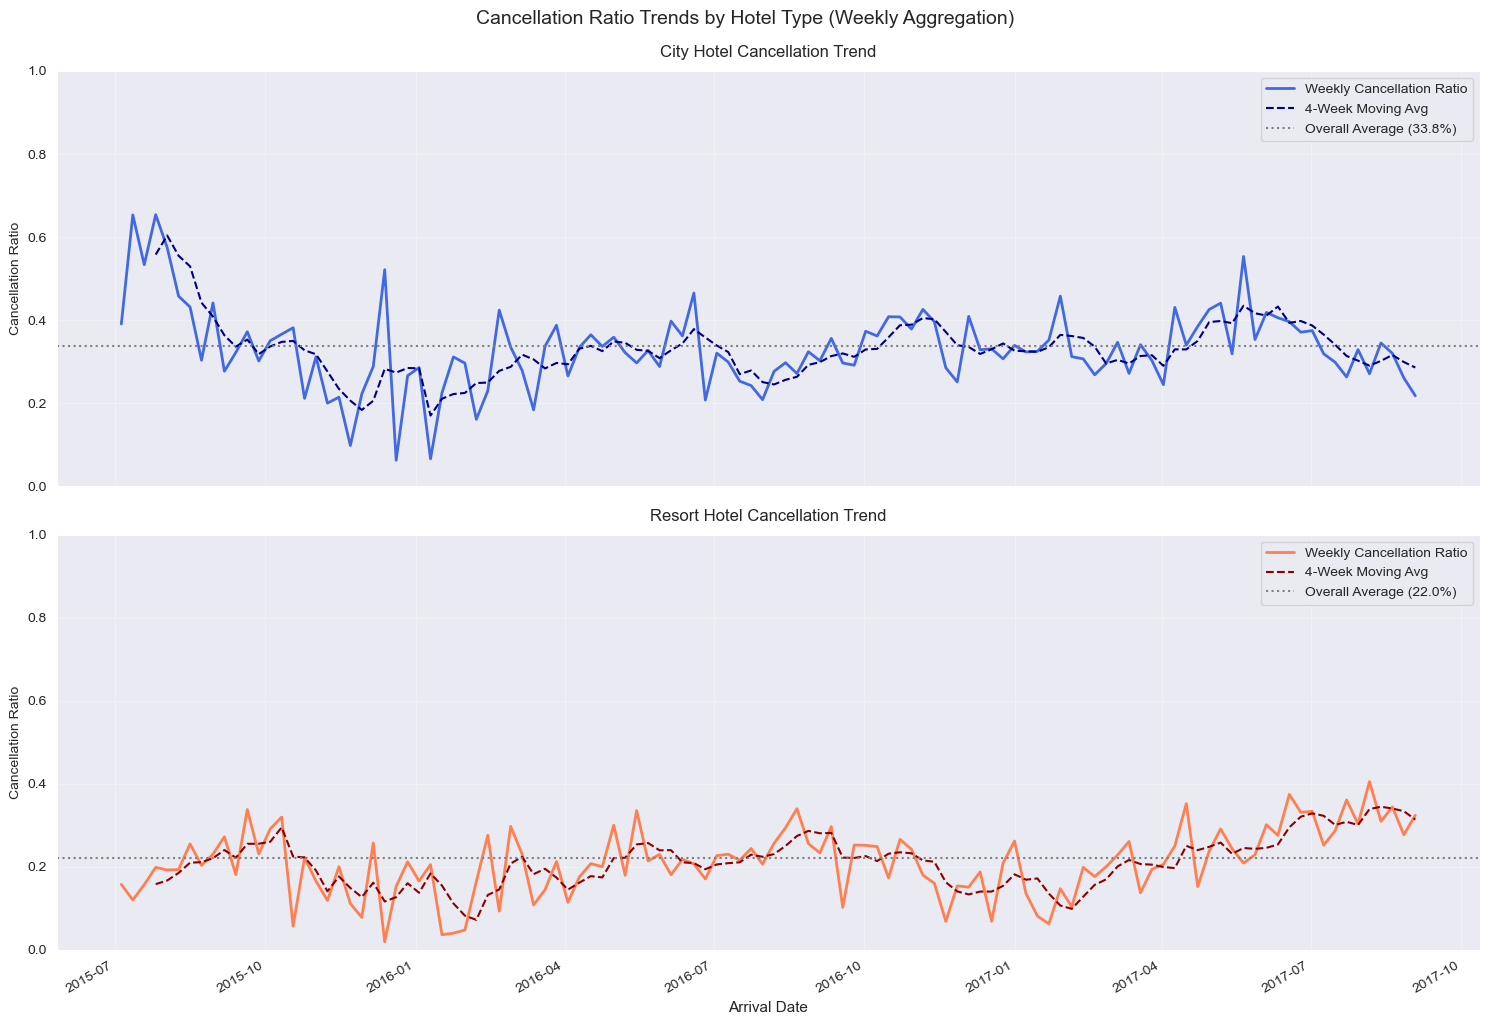

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for ax, hotel_type in zip([ax1, ax2], ['City Hotel', 'Resort Hotel']):
    hotel_data = train[train['hotel'] == hotel_type]
    cancel_ratio = hotel_data.set_index('arrival_date').groupby(pd.Grouper(freq='W'))['is_canceled'].mean()

    sns.lineplot(x=cancel_ratio.index, y=cancel_ratio.values,
                 ax=ax, color='royalblue' if hotel_type == 'City Hotel' else 'coral',
                 linewidth=2, label='Weekly Cancellation Ratio')

    cancel_ratio.rolling(4).mean().plot(
        ax=ax, color='navy' if hotel_type == 'City Hotel' else 'darkred',
        linestyle='--', label='4-Week Moving Avg')

    avg = hotel_data['is_canceled'].mean()
    ax.axhline(avg, color='gray', linestyle=':',
               label=f'Overall Average ({avg:.1%})')

    ax.set_title(f'{hotel_type} Cancellation Trend', fontsize=12, pad=10)
    ax.set_ylabel('Cancellation Ratio', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_ylim(0, 1)

ax2.set_xlabel('Arrival Date', fontsize=11)
plt.tight_layout()
plt.suptitle('Cancellation Ratio Trends by Hotel Type (Weekly Aggregation)', y=1.02, fontsize=14)
plt.show()

- Доля отмен в городских отелях (33.8%) в среднем в полтора раза выше, чем в курортных отелях (22.0%)
- Диапазон колебаний долей отмен у городских отелей шире (20-50%), чем у курортных отелей (10-30%)

In [9]:
cols = ['stays_in_weekend_nights','stays_in_week_nights','total_nights', 'adults','children','babies','total_guests', 'total_of_special_requests','special_requests_per_guest']

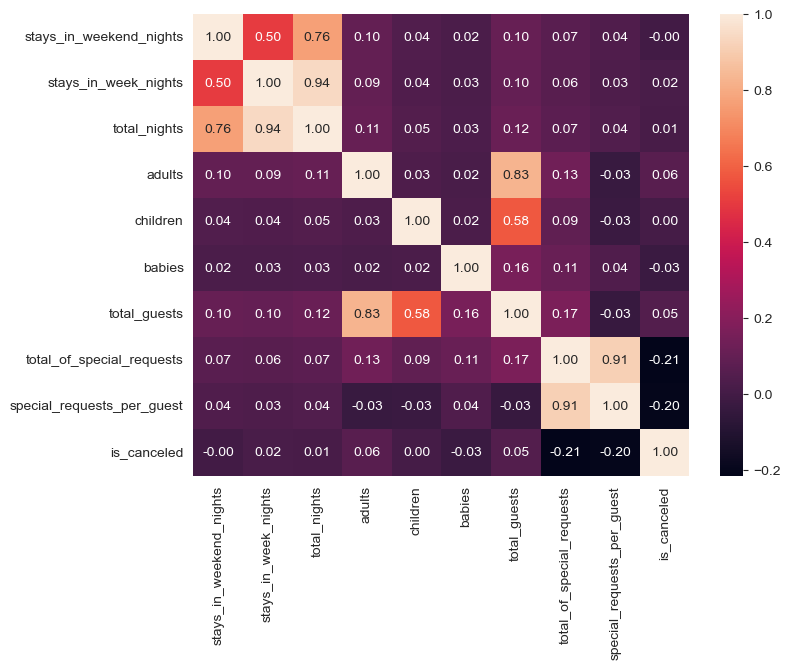

In [10]:
train_2 = pd.read_csv("train_final_processed.csv")
train[['total_nights', 'total_guests', 'special_requests_per_guest']] = train_2[['total_nights', 'total_guests', 'special_requests_per_guest']]

corr = train[cols + ['is_canceled']].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()

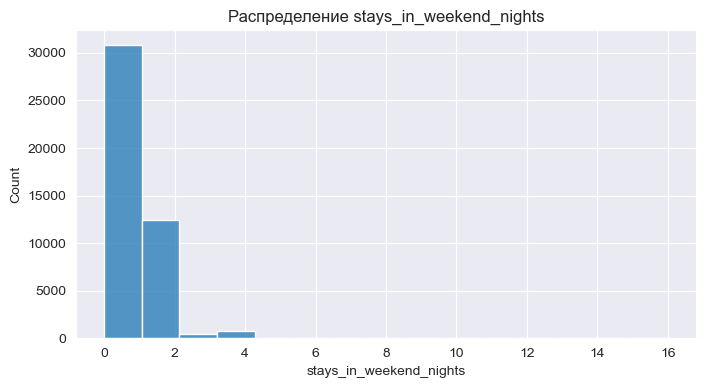

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(train['stays_in_weekend_nights'], bins=15)
plt.title('Распределение stays_in_weekend_nights')
plt.xlabel('stays_in_weekend_nights')
plt.show()

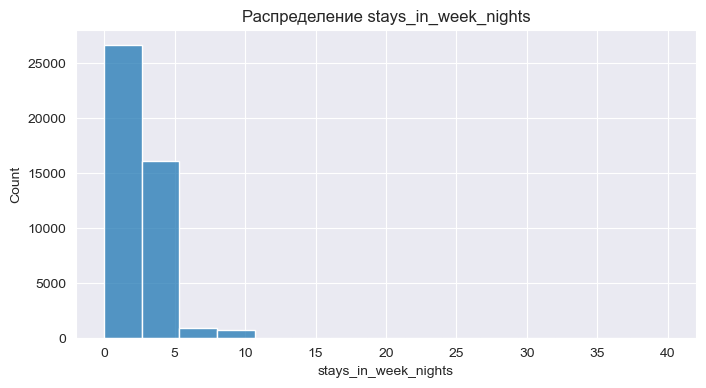

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(train['stays_in_week_nights'], bins=15)
plt.title('Распределение stays_in_week_nights')
plt.xlabel('stays_in_week_nights')
plt.show()

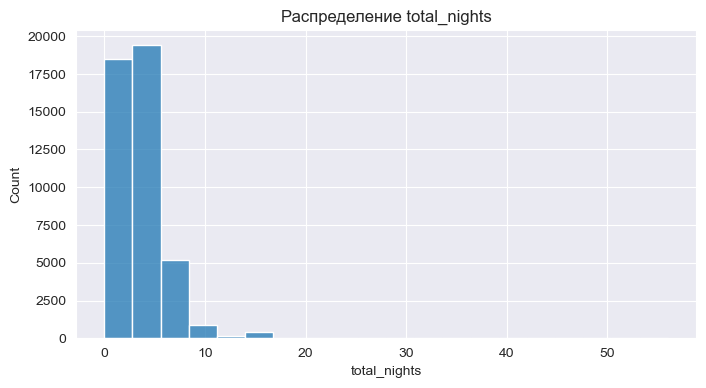

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(train['total_nights'], bins=20)
plt.title('Распределение total_nights')
plt.xlabel('total_nights')
plt.show()

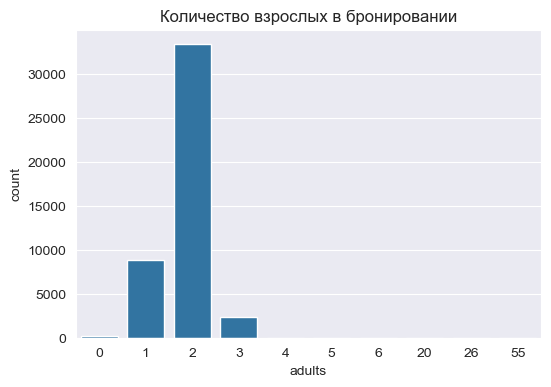

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x=train['adults'])
plt.title('Количество взрослых в бронировании')
plt.xlabel('adults')
plt.show()

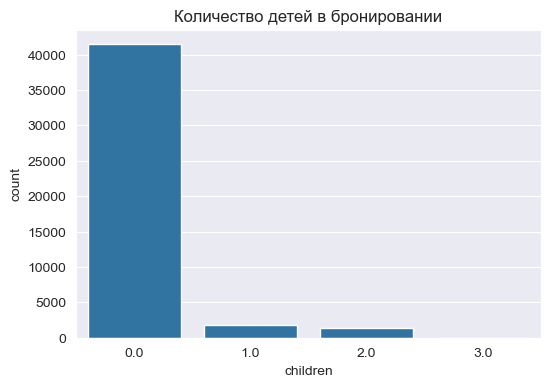

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x=train['children'])
plt.title('Количество детей в бронировании')
plt.xlabel('children')
plt.show()

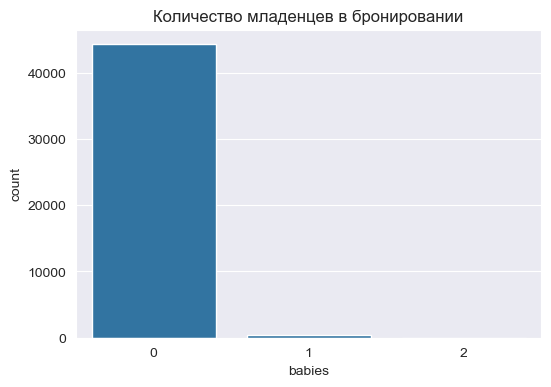

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x=train['babies'])
plt.title('Количество младенцев в бронировании')
plt.xlabel('babies')
plt.show()

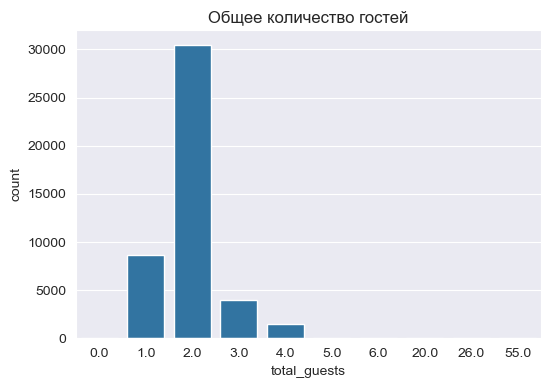

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x=train['total_guests'])
plt.title('Общее количество гостей')
plt.xlabel('total_guests')
plt.show()

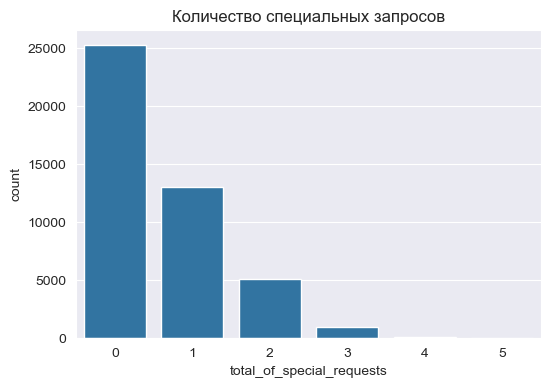

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x=train['total_of_special_requests'])
plt.title('Количество специальных запросов')
plt.xlabel('total_of_special_requests')
plt.show()

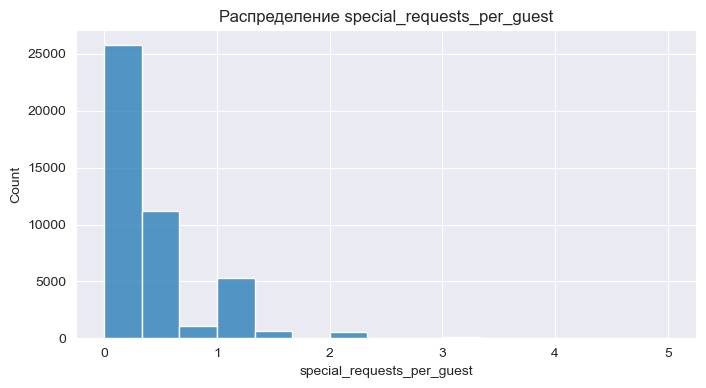

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(train['special_requests_per_guest'].dropna(), bins=15)
plt.title('Распределение special_requests_per_guest')
plt.xlabel('special_requests_per_guest')
plt.show()

# Выводы:

- Большинство гостей приезжают на 1-2 ночи, как в будние, так и в выходные.
- В номере чаще всего проживают 2 взрослых, дети и младенцы встречаются редко. Дети/младенцы сами по себе на отмену почти не влияют,
их влияние проявится только вместе с другими факторами.
- Почти все бронирования — без специальных запросов, но если они есть, то обычно 1-2 запроса. При этом если человек написал хоть один запрос, то он заметно реже отменяет.
- Чем больше компания, тем немного выше риск отмены. Связь слабая, но есть: у групп 3-4 человека отмен чуть больше, чем у пар.

In [20]:
cols = [
	'meal',
	'country',
	'market_segment',
	'distribution_channel',
	'required_car_parking_spaces'
]
train[['meal', 'country', 'market_segment', 'distribution_channel']] = train_2[['meal', 'country', 'market_segment', 'distribution_channel']]

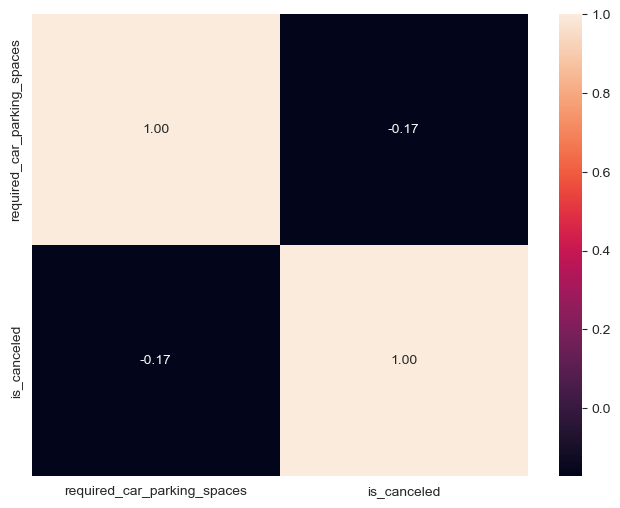

In [21]:
corr = train[cols + ["is_canceled"]].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

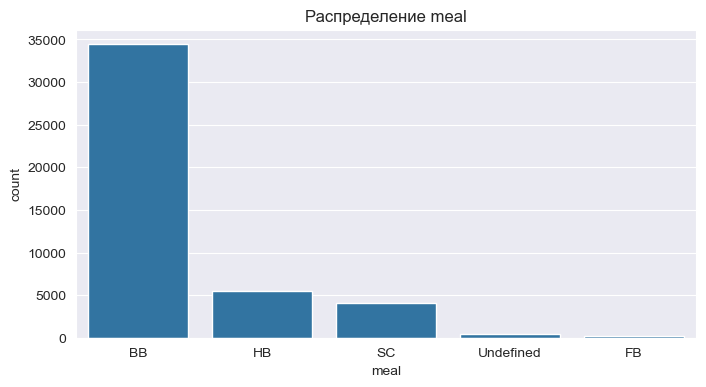

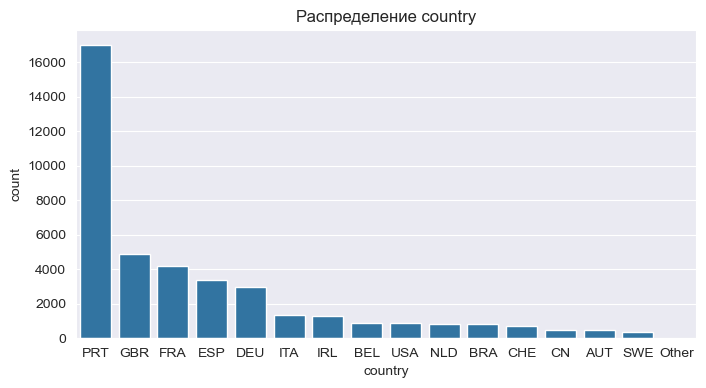

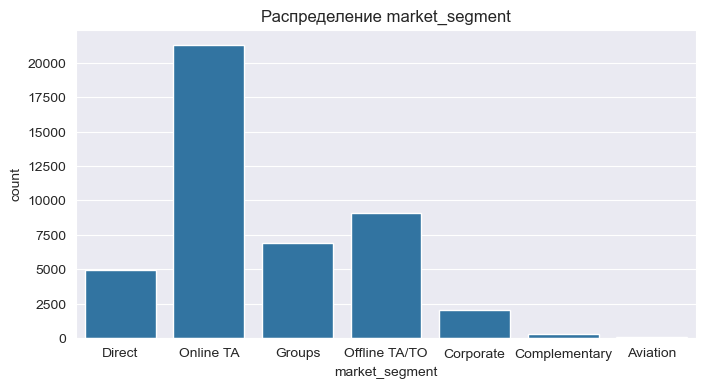

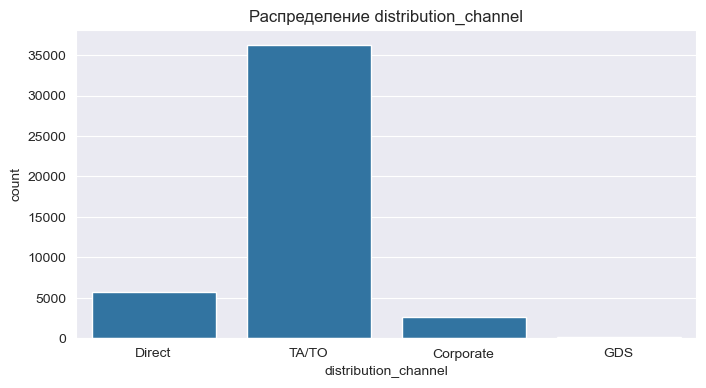

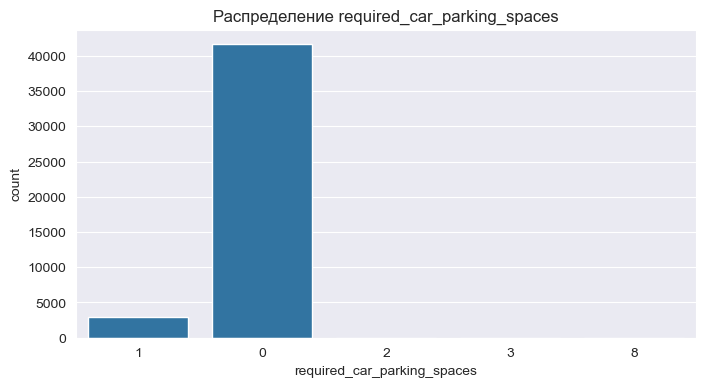

In [22]:
for column in cols:
	plt.figure(figsize=(8,4))

	if column == 'country':
		top_10 = train[column].value_counts().nlargest(15).index
		data_to_plot = train[column].apply(lambda x: x if x in top_10 else 'Other')
		_order = list(top_10) + ['Other']
	else:
		data_to_plot = train[column]
		_order = list(train[column])

	sns.countplot(x=train[column], order=_order)
	plt.title(f'Распределение {column}')
	plt.xlabel(column)
	plt.show()

In [23]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

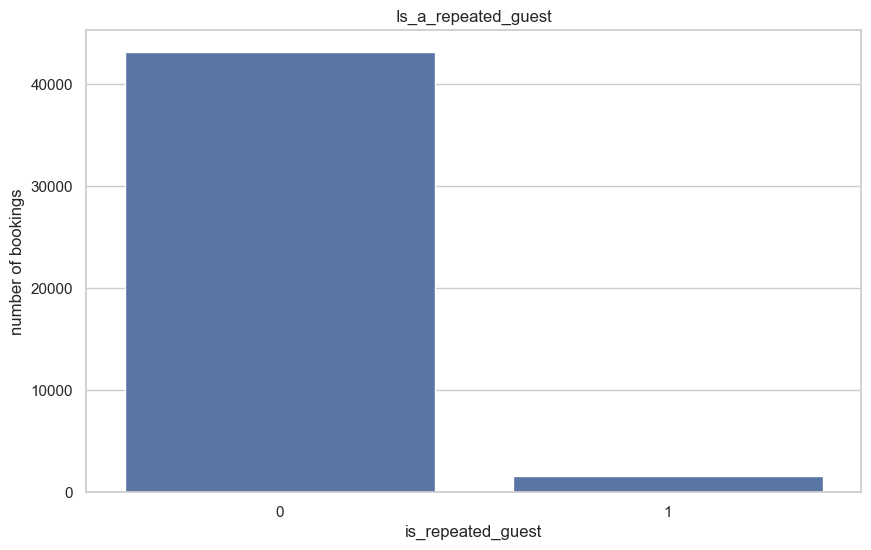

In [25]:
plt.figure()
sns.countplot(data=train, x='is_repeated_guest')
plt.title("Is_a_repeated_guest")
plt.xlabel("is_repeated_guest")
plt.ylabel("number of bookings")
plt.show()

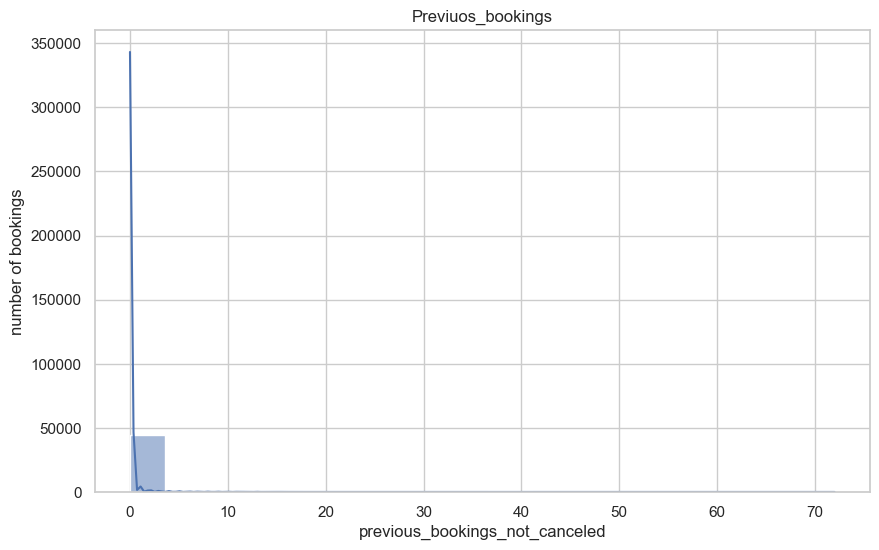

In [26]:
plt.figure()
sns.histplot(data=train, x='previous_bookings_not_canceled', bins=20, kde=True)
plt.title("Previuos_bookings")
plt.xlabel("previous_bookings_not_canceled")
plt.ylabel("number of bookings")
plt.show()

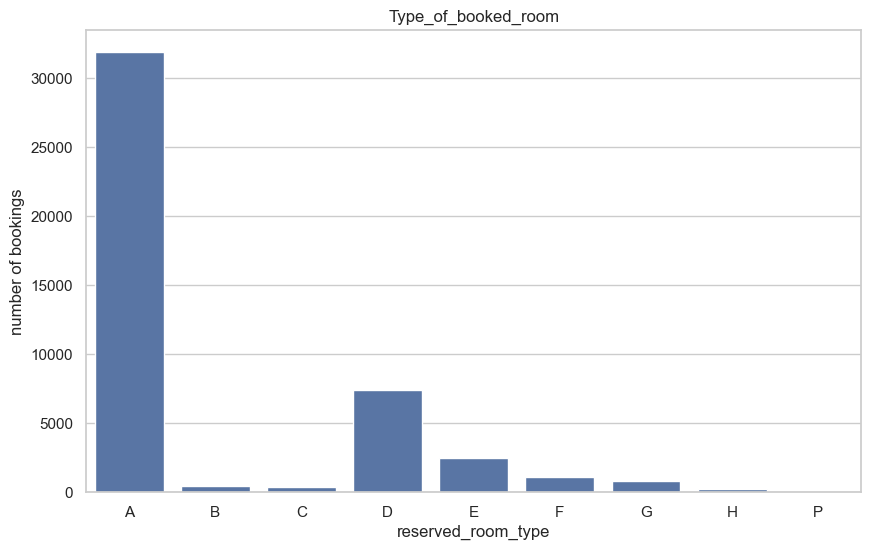

In [29]:
plt.figure()
sns.countplot(data=train, x='reserved_room_type', order=sorted(train['reserved_room_type'].unique()))
plt.title("Type_of_booked_room")
plt.xlabel("reserved_room_type")
plt.ylabel("number of bookings")
plt.show()

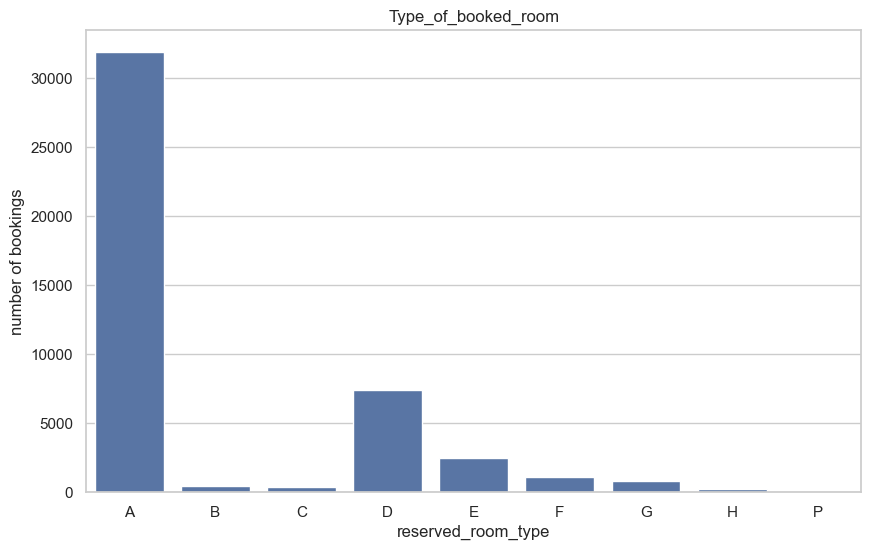

In [30]:
plt.figure()
sns.countplot(data=train, x='reserved_room_type', order=sorted(train['reserved_room_type'].unique()))
plt.title("Type_of_booked_room")
plt.xlabel("reserved_room_type")
plt.ylabel("number of bookings")
plt.show()

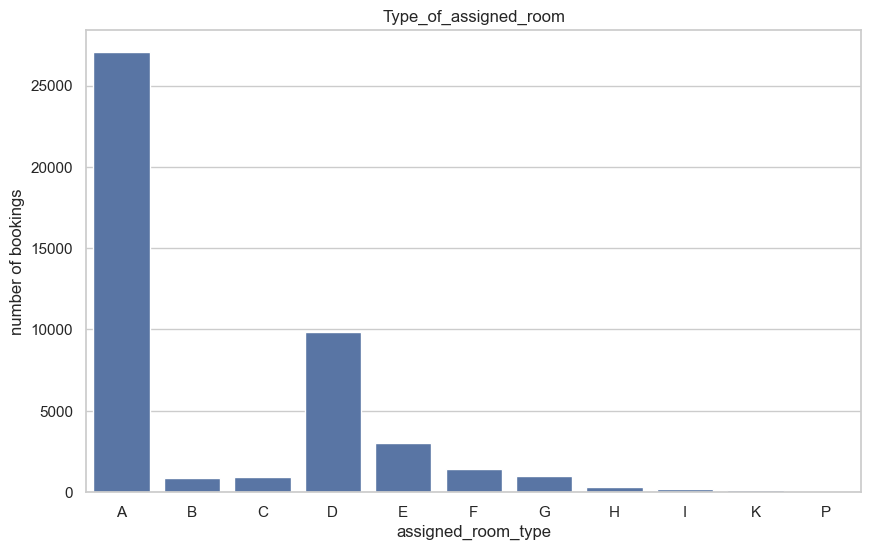

In [31]:
plt.figure()
sns.countplot(data=train, x='assigned_room_type', order=sorted(train['assigned_room_type'].unique()))
plt.title("Type_of_assigned_room")
plt.xlabel("assigned_room_type")
plt.ylabel("number of bookings")
plt.show()

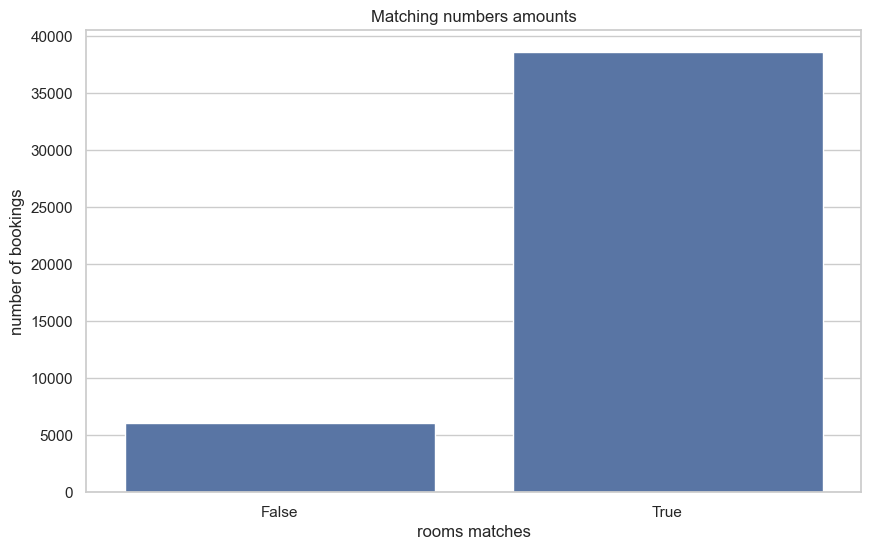

In [32]:
train['room_match'] = train['reserved_room_type'] == train['assigned_room_type']

plt.figure()
sns.countplot(data=train, x='room_match')
plt.title("Matching numbers amounts")
plt.xlabel("rooms matches")
plt.ylabel("number of bookings")
plt.show()

In [33]:
cols = ["booking_changes", "deposit_type", "days_in_waiting_list", "customer_type", "adr"]

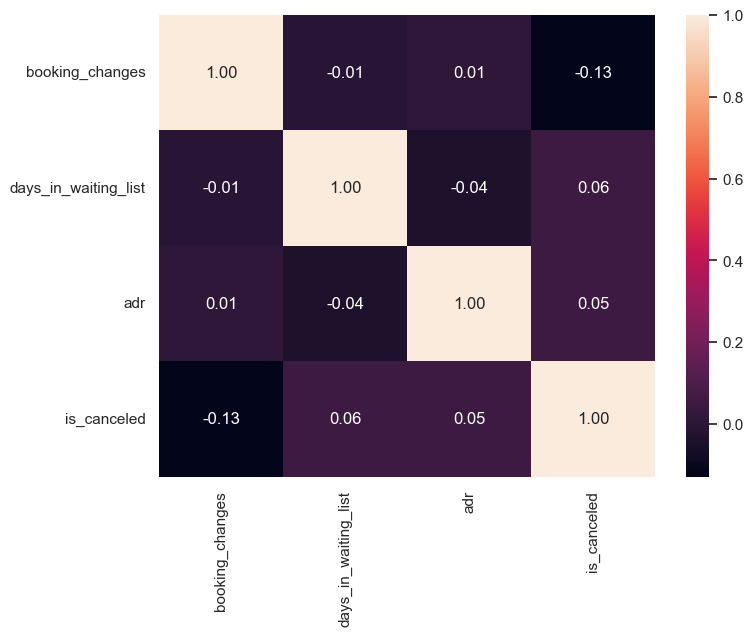

In [34]:
corr = train[cols + ["is_canceled"]].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

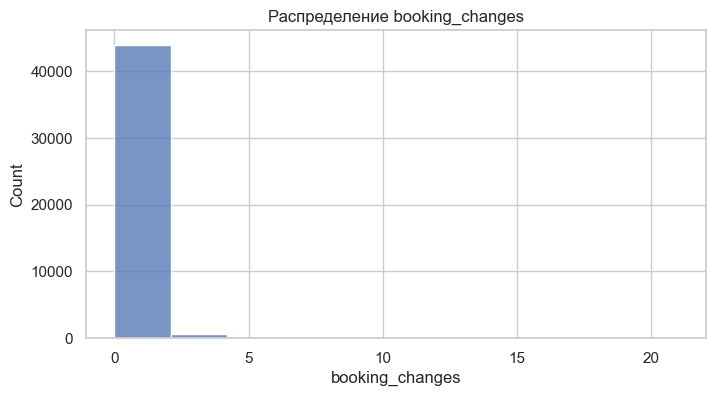

In [35]:
plt.figure(figsize=(8,4))
sns.histplot(train["booking_changes"].dropna(), bins=10)
plt.title("Распределение booking_changes")
plt.xlabel("booking_changes")
plt.show()

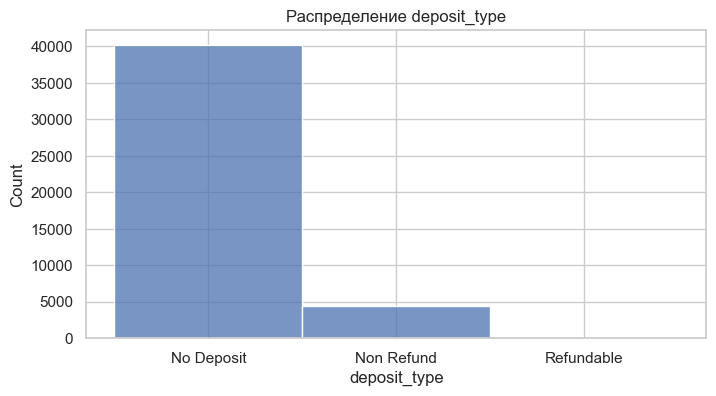

In [36]:
plt.figure(figsize=(8,4))
sns.histplot(train["deposit_type"].dropna(), bins=10)
plt.title("Распределение deposit_type")
plt.xlabel("deposit_type")
plt.show()

In [37]:
e_df = train[train["deposit_type"] == "Non Refund"]
e_df["is_canceled"].value_counts()

is_canceled
1    4295
0      44
Name: count, dtype: int64

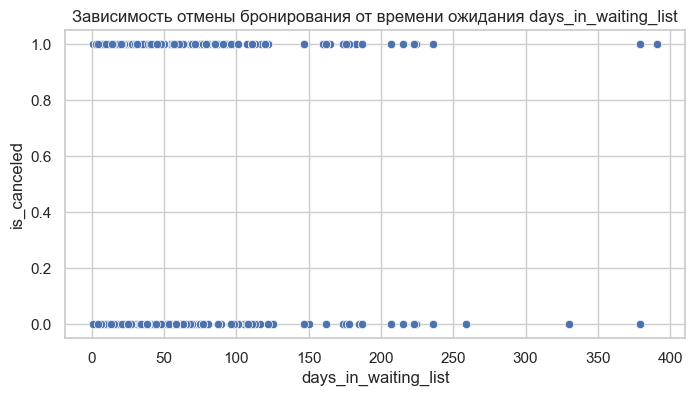

In [38]:
e_df = train[train["days_in_waiting_list"] != 0]
plt.figure(figsize=(8,4))
sns.scatterplot(data=e_df, x="days_in_waiting_list", y="is_canceled")
plt.title("Зависимость отмены бронирования от времени ожидания days_in_waiting_list")
plt.show()

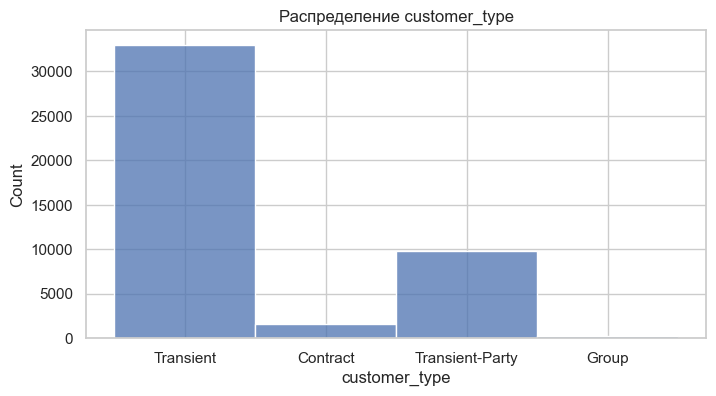

In [39]:
plt.figure(figsize=(8,4))
sns.histplot(train["customer_type"].dropna(), bins=10)
plt.title("Распределение customer_type")
plt.xlabel("customer_type")
plt.show()

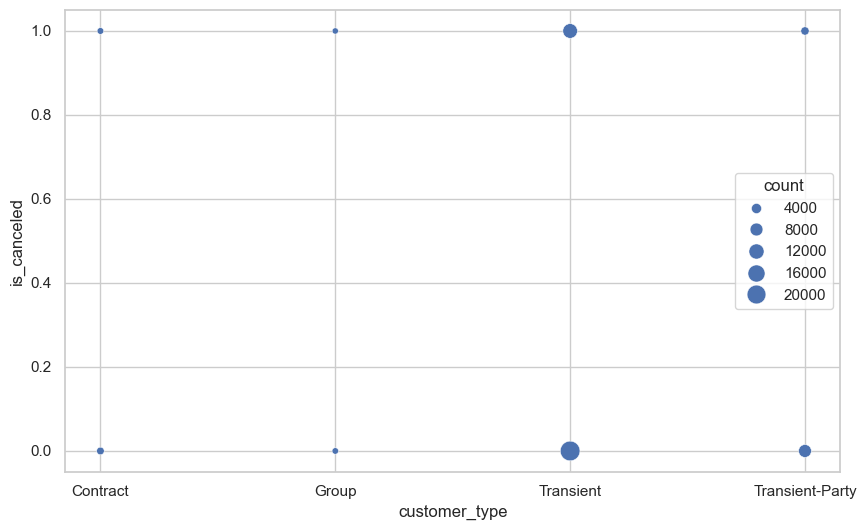

In [40]:
e_df = train.groupby(["customer_type", "is_canceled"]).size().reset_index(name="count")
sns.scatterplot(data=e_df, x="customer_type", y="is_canceled", size="count", sizes=(20, 200))
plt.show()

In [41]:
for t in train["customer_type"].unique():
    corr_df = train[train["customer_type"] == t]
    v = corr_df["is_canceled"].value_counts()
    print(t)
    print(v)

Transient
is_canceled
0    21971
1    11011
Name: count, dtype: int64
Contract
is_canceled
0    1223
1     371
Name: count, dtype: int64
Transient-Party
is_canceled
0    7943
1    1883
Name: count, dtype: int64
Group
is_canceled
0    217
1     19
Name: count, dtype: int64


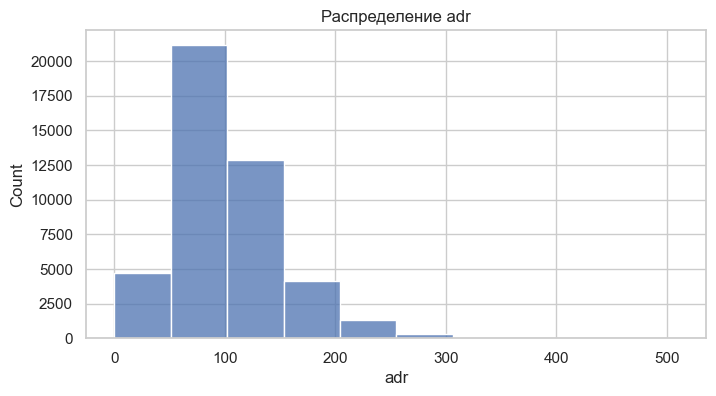

In [42]:
plt.figure(figsize=(8,4))
sns.histplot(train["adr"].dropna(), bins=10)
plt.title("Распределение adr")
plt.xlabel("adr")
plt.show()

In [43]:
quantiles = [0.1, 0.25, 0.5, 1]
for q in quantiles:
    th = train["adr"].quantile(q)
    e_df = train[train["adr"] < th]
    v = e_df["is_canceled"].value_counts()
    print(f"{q * 100}%")
    print(v)

10.0%
is_canceled
0    3788
1     676
Name: count, dtype: int64
25.0%
is_canceled
0    8220
1    2939
Name: count, dtype: int64
50.0%
is_canceled
0    16043
1     6173
Name: count, dtype: int64
100%
is_canceled
0    31353
1    13284
Name: count, dtype: int64


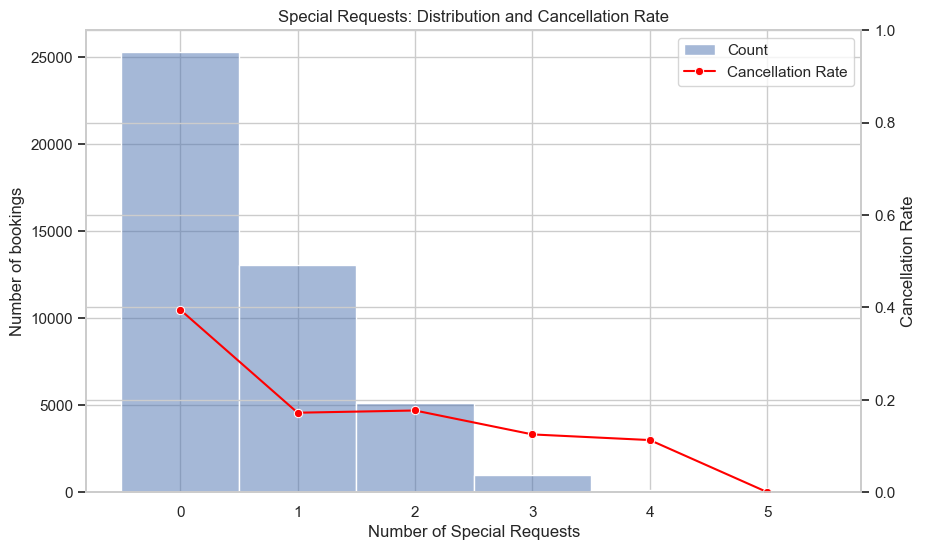

In [44]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=train, x='total_of_special_requests', bins=np.arange(0, train['total_of_special_requests'].max()+1)-0.5,
                  discrete=True, alpha=0.5, label='Count')

ax2 = ax.twinx()
sns.lineplot(data=train.groupby('total_of_special_requests')['is_canceled'].mean().reset_index(),
             x='total_of_special_requests', y='is_canceled', color='red', 
             marker='o', ax=ax2, label='Cancellation Rate')

ax.set_title('Special Requests: Distribution and Cancellation Rate')
ax.set_xlabel('Number of Special Requests')
ax.set_ylabel('Number of bookings')
ax2.set_ylabel('Cancellation Rate')
ax2.tick_params(axis='y')
ax2.set_ylim(0, 1)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.show()


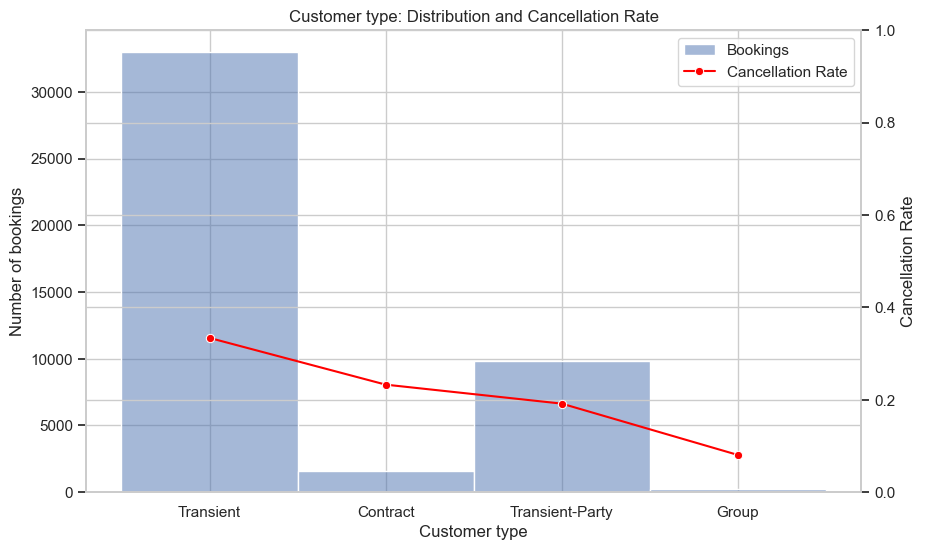

In [45]:
ax = sns.histplot(data=train, x='customer_type',
                  discrete=True, alpha=0.5, label='Bookings')

ax2 = ax.twinx()
sns.lineplot(data=train.groupby('customer_type')['is_canceled'].mean().reset_index(),
             x='customer_type', y='is_canceled', color='red',
             marker='o', ax=ax2, label='Cancellation Rate')

ax.set_title('Customer type: Distribution and Cancellation Rate')
ax.set_xlabel('Customer type')
ax.set_ylabel('Number of bookings')
ax2.set_ylabel('Cancellation Rate')
ax2.tick_params(axis='y')
ax2.set_ylim(0, 1)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.show()

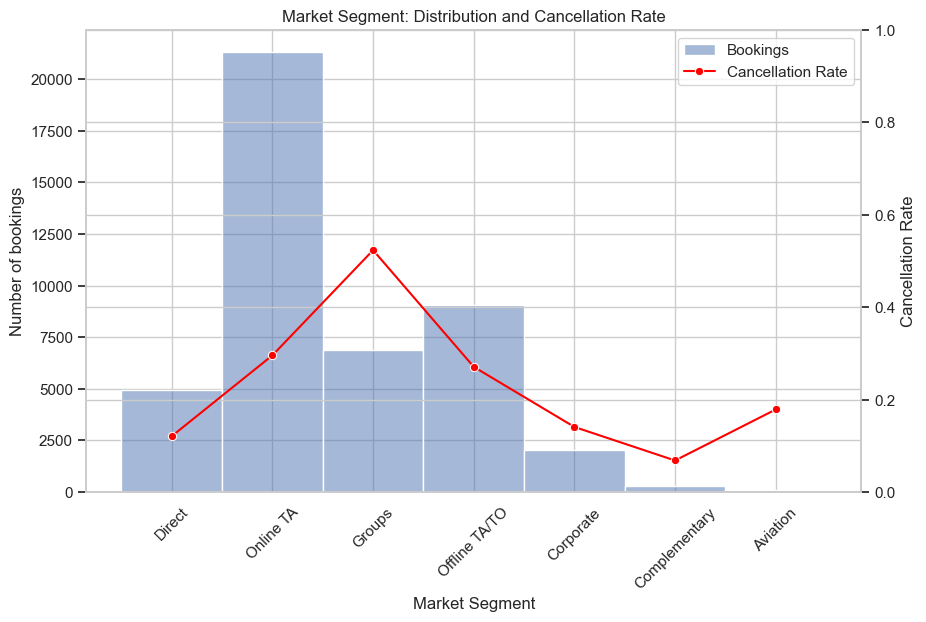

In [46]:
ax = sns.histplot(data=train, x='market_segment',
                  discrete=True, alpha=0.5, label='Bookings')

ax2 = ax.twinx()
sns.lineplot(data=train.groupby('market_segment')['is_canceled'].mean().reset_index(),
             x='market_segment', y='is_canceled', color='red',
             marker='o', ax=ax2, label='Cancellation Rate')

ax.set_title('Market Segment: Distribution and Cancellation Rate')
ax.set_xlabel('Market Segment')
ax.set_ylabel('Number of bookings')
ax.tick_params(axis='x', rotation=45)
ax2.set_ylabel('Cancellation Rate')
ax2.tick_params(axis='y')
ax2.set_ylim(0, 1)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.show()

Выводы:

*  Большинство гостей не вносит изменения в бронирование и не использует депозит.
*  Клиенты c залогом в размере полной стоимости проживания очень часто отменяют бронирование.
*  Очень слабая зависимость отмены заказа и времени ожидания.
*  Отмен среди корпоративных клиентов и тех, кто путешествует группой, меньше.
*  В среднем, чем дешевле номер, тем меньше вероятность его отмены.


